## Loading all the necessary libraries

In [190]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

## Loading Data

In [191]:
data_location = "final_parsed_metrics.csv"

data = pd.read_csv(data_location)
data.head(5)
# print(data.shape)

,name of circuit,tech node,antenna__violating__nets,antenna__violating__pins,clock__skew__worst_hold,clock__skew__worst_setup,design__core__area,design__core__bbox,design__critical_disconnected_pin__count,design__die__area,...,timing__hold_r2r_vio__count,timing__hold_vio__count,timing__setup__tns,timing__setup__wns,timing__setup__ws,timing__setup_r2r__ws,timing__setup_r2r_vio__count,timing__setup_vio__count,timing__unannotated_net__count,timing__unannotated_net_filtered__count
0,APU,180nm,0.0,0.0,0.733007,0.260119,284217.000,6.72 15.68 539.84 548.8,0.0,308622.0,...,0.0,0.0,0.0,0.0,43.257347,50.304146,0.0,0.0,0.0,0.0
1,blink,180nm,0.0,0.0,-0.003560,-0.008334,6146.560,6.72 15.68 85.12 94.08,0.0,10108.6,...,0.0,0.0,0.0,0.0,0.065277,0.065277,0.0,0.0,0.0,0.0
2,cell_inverter,180nm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,inverter,180nm,0.0,0.0,NaN,NaN,570.752,6.72 15.68 43.12 31.36,NaN,2500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,latch_bad,180nm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Getting Subset of a data and removing NA

In [ ]:
# print(data.columns)
area_data = data[[
    'tech node',
    'name of circuit',
    'design__instance__area',
    'design__instance__area__macros',
    'design__instance__area__stdcell',
    'design__io',
    'design__instance__count',
    'design__instance__count__stdcell',
    'design__instance__count__macros',
    'design__inferred_latch__count',
    'design__instance__count__hold_buffer',
    'design__instance__count__setup_buffer',
    'design__core__area']]
# area_data.head(5)

In [ ]:
area_data = area_data.dropna(subset=['design__instance__count', 'design__core__area'], how='any')
zero_instance = area_data[area_data['design__instance__count'] == 0]
area_data = area_data.dropna(subset=['design__instance__count__hold_buffer', 'design__instance__count__macros', 'design__instance__count__setup_buffer', 'design__instance__count__stdcell', 'design__inferred_latch__count'], how='any')

print(zero_instance.shape)
print(area_data.shape)
print(area_data.isna().any())
area_data.head(5)

(0, 13)
(20821, 13)
tech node                                False
name of circuit                          False
design__instance__area                   False
design__instance__area__macros           False
design__instance__area__stdcell          False
design__io                               False
design__instance__count                  False
design__instance__count__stdcell         False
design__instance__count__macros          False
design__inferred_latch__count            False
design__instance__count__hold_buffer     False
design__instance__count__setup_buffer    False
design__core__area                       False
dtype: bool


,tech node,name of circuit,design__instance__area,design__instance__area__macros,design__instance__area__stdcell,design__io,design__instance__count,design__instance__count__stdcell,design__instance__count__macros,design__inferred_latch__count,design__instance__count__hold_buffer,design__instance__count__setup_buffer,design__core__area
0,180nm,APU,107602.0,0.0,107602.0,77.0,7130.0,7130.0,0.0,0.0,1.0,0.0,284217.0
6,180nm,spm,11621.4,0.0,11621.4,38.0,593.0,593.0,0.0,0.0,0.0,0.0,21280.3
7,180nm,usb,31501.1,0.0,31501.1,46.0,1361.0,1361.0,0.0,0.0,0.0,0.0,59885.1
8,180nm,usb_cdc_core,73679.7,0.0,73679.7,55.0,4230.0,4230.0,0.0,0.0,4.0,46.0,157640.0
9,180nm,wbqspiflash,67873.4,0.0,67873.4,106.0,3028.0,3028.0,0.0,0.0,0.0,39.0,94345.3


## Visualizing the data

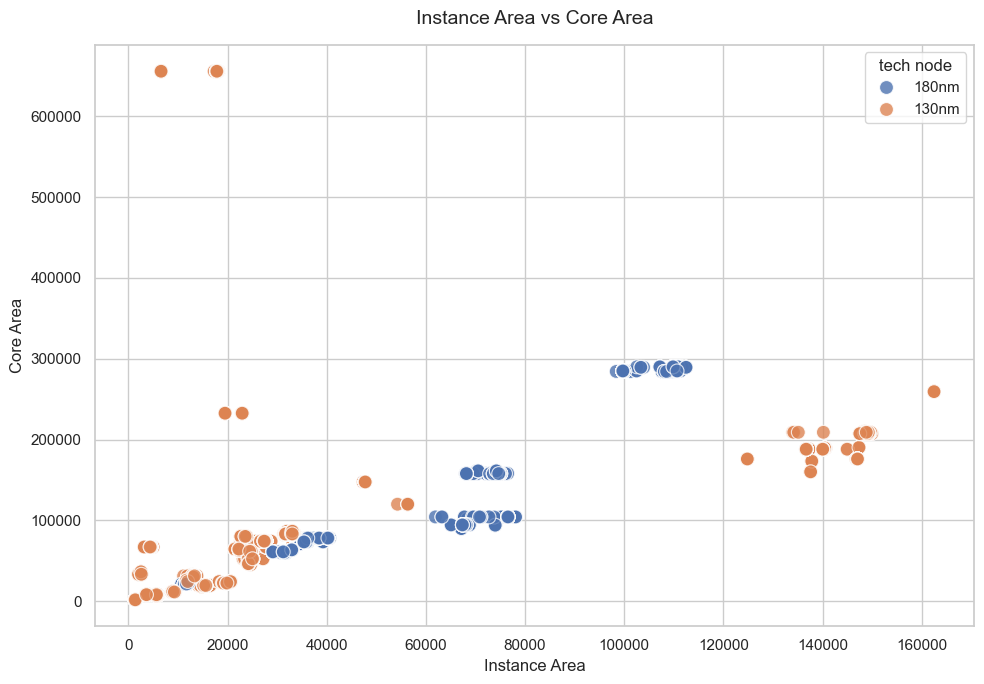

In [194]:
# plt.scatter(area_data['design__instance__area'], area_data['design__core__area'])
# plt.xlabel('instance_area')
# plt.ylabel('core area')
# # plt.xlim(0, 50)
# plt.show()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))

ax = sns.scatterplot(
    data=area_data,
    x="design__instance__area",
    y="design__core__area",
    hue="tech node",
    palette="deep",
    s=100,  # Make points larger and easier to see
    alpha=0.8,
)

plt.xlabel("Instance Area", fontsize=12)
plt.ylabel("Core Area", fontsize=12)
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  
plt.title("Instance Area vs Core Area", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

some points are outling need to check those points.

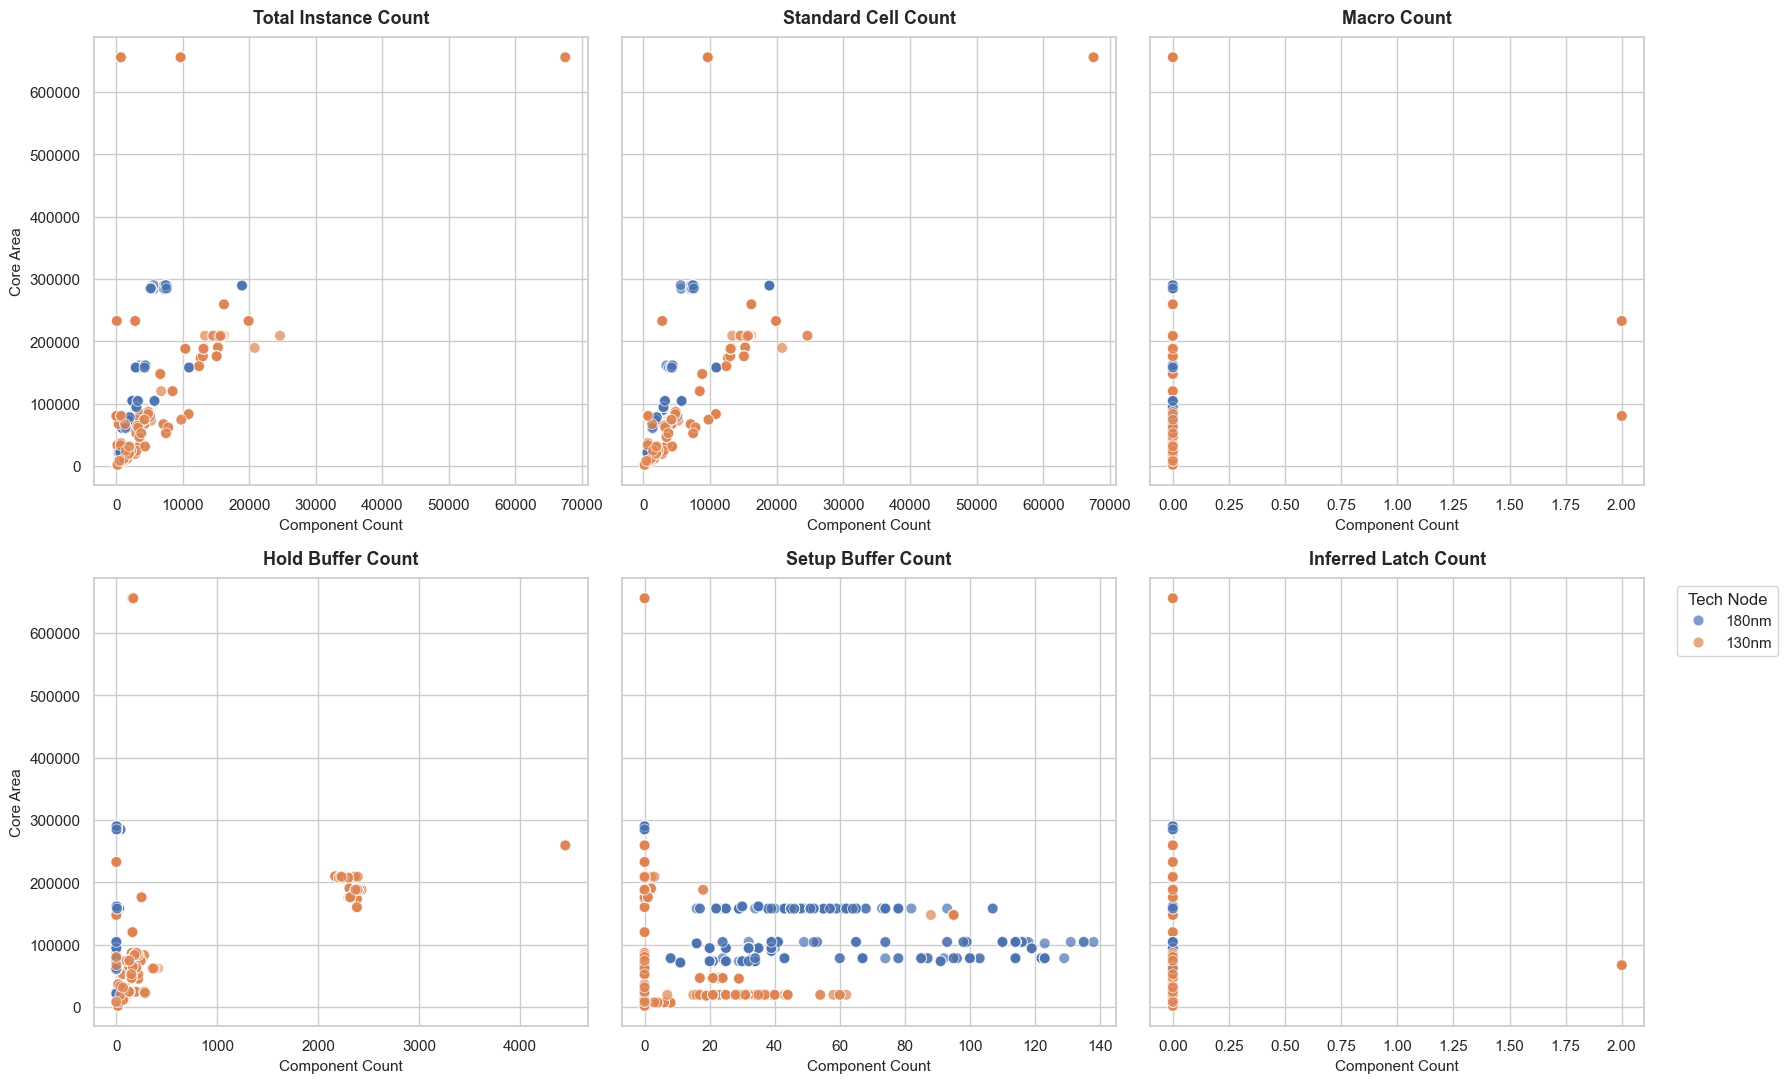

In [195]:
# plt.scatter(area_data['design__instance__count__stdcell'], area_data['design__core__area'])
# plt.xlabel('instance count stdcell')
# plt.ylabel('core area')
# # plt.xlim(0, 50)
# plt.show()

plot_config = [
    {"col": "design__instance__count", "title": "Total Instance Count"},
    {"col": "design__instance__count__stdcell", "title": "Standard Cell Count"},
    {"col": "design__instance__count__macros", "title": "Macro Count"},
    {"col": "design__instance__count__hold_buffer", "title": "Hold Buffer Count"},
    {"col": "design__instance__count__setup_buffer", "title": "Setup Buffer Count"},
    {"col": "design__inferred_latch__count", "title": "Inferred Latch Count"},
]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharey=True)
# plt.figure(figsize=(10, 7))
axes = axes.flatten()

for i, config in enumerate(plot_config):
    sns.scatterplot(
        data=area_data,
        x=config["col"],
        y="design__core__area",
        hue="tech node",  
        palette="deep",
        ax=axes[i], 
        s=60,
        alpha=0.7,
    )
    axes[i].set_title(config["title"], fontsize=13, fontweight="bold", pad=10)
    axes[i].set_xlabel("Component Count", fontsize=11)

    if i % 3 == 0:
        axes[i].set_ylabel("Core Area", fontsize=11)
    else:
        axes[i].set_ylabel("")

    if i != 5:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title="Tech Node", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

need to check some zero stdcell instance

<function matplotlib.pyplot.show(close=None, block=None)>

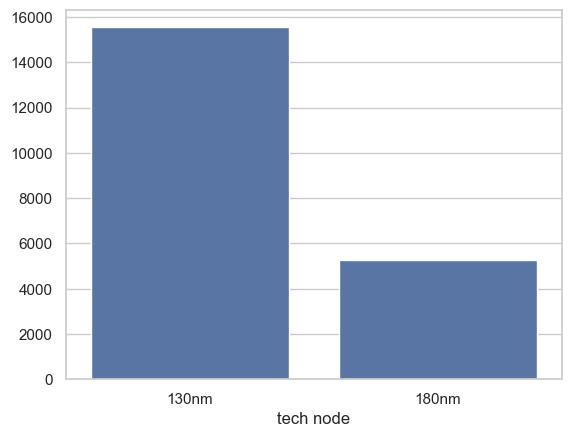

In [196]:
count = area_data['tech node'].value_counts()
sns.set_theme(style="whitegrid")
sns.barplot(x=count.index, y=count.values)
plt.show

Data is not balcanced it is more biased towards 130nm tech node

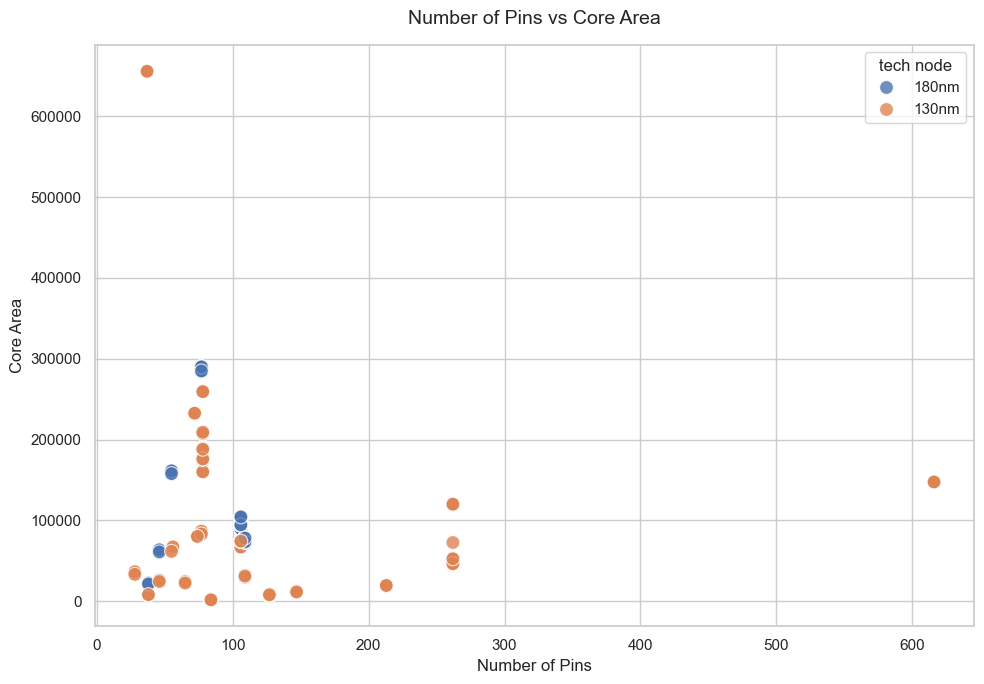

In [ ]:
# plt.scatter(area_data['design__io'], area_data['design__core__area'])
# plt.xlabel('design__io')
# plt.ylabel('core area')
# # plt.xlim(0, 50)
# plt.show()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))

ax = sns.scatterplot(
    data=area_data,
    x="design__io",
    y="design__core__area",
    hue="tech node",
    palette="deep",
    s=100,  # Make points larger and easier to see
    alpha=0.8,
)

plt.xlabel("Number of Pins", fontsize=12)
plt.ylabel("Core Area", fontsize=12)
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  
plt.title("Number of Pins vs Core Area", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Data Encoding and Standardization

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

tech_node_categories = [['180nm', '130nm']]
ordinal_feature = ['tech node']
ordinal_encoder = OrdinalEncoder(categories=tech_node_categories)



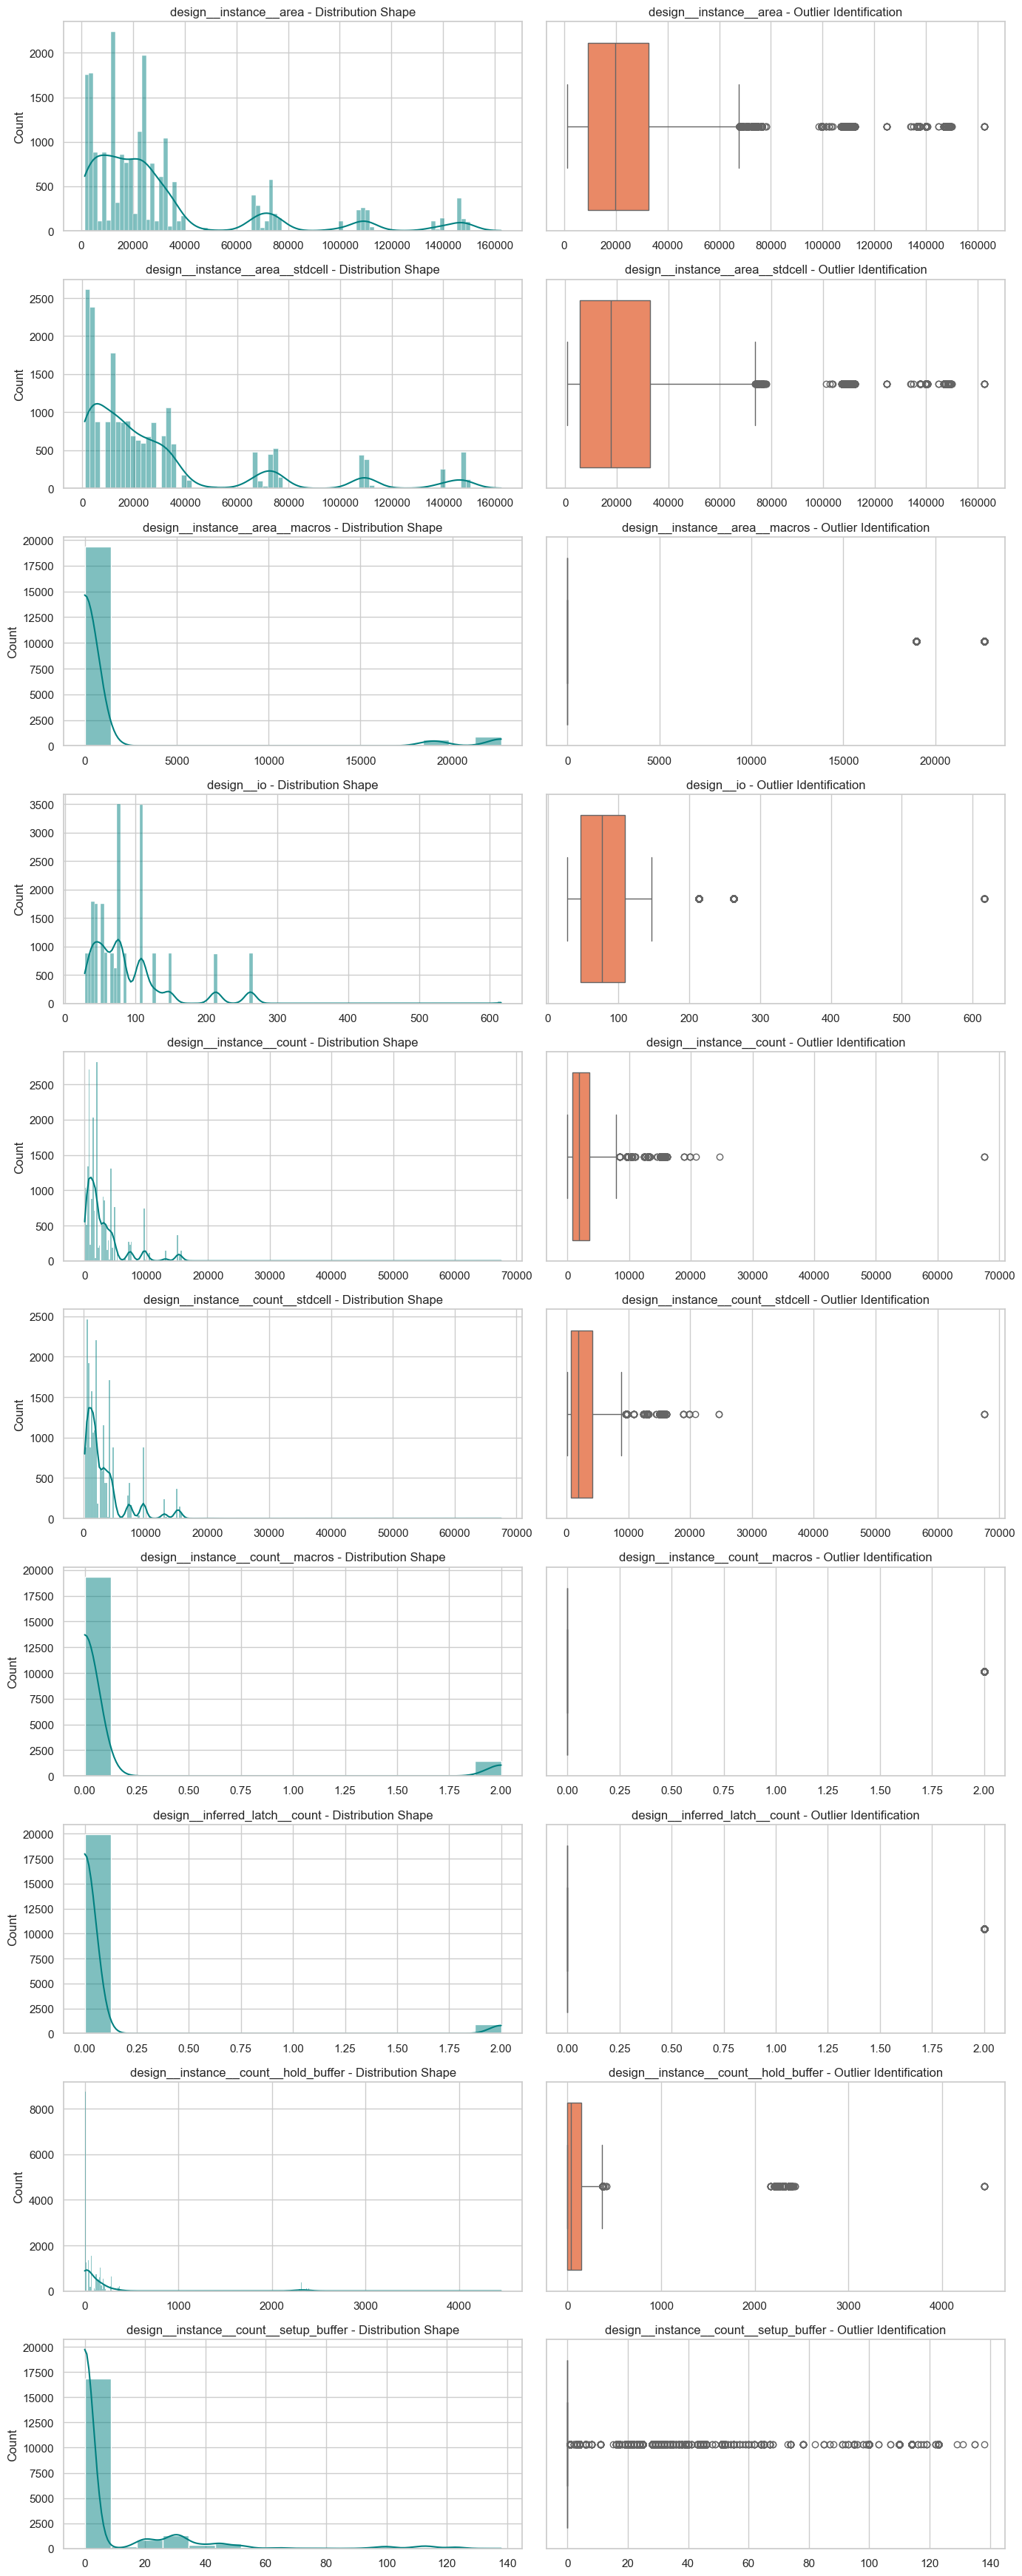

In [ ]:
features_to_check = [
    'design__instance__area', 
    'design__instance__area__stdcell',
    'design__instance__area__macros',
    'design__io', 
    'design__instance__count',
    'design__instance__count__stdcell',
    'design__instance__count__macros',
    'design__inferred_latch__count',
    'design__instance__count__hold_buffer',
    'design__instance__count__setup_buffer'
]

fig, axes = plt.subplots(nrows=len(features_to_check), ncols=2, figsize=(14, 3.5 * len(features_to_check)))

for i, col in enumerate(features_to_check):
    sns.histplot(data=area_data, x=col, kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'{col} - Distribution Shape')
    axes[i, 0].set_xlabel('') 
    
    sns.boxplot(data=area_data, x=col, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'{col} - Outlier Identification')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


ct = ColumnTransformer(transformers=[('ord', ordinal_encoder, ordinal_feature),
                                     ('num', StandardScaler(), features_to_check)])
ct.set_output(transform='pandas')

y = area_data['design__core__area']
x = area_data.drop(columns=['design__core__area'])

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, stratify=x['tech node'], random_state=148)

X_train_scaled = ct.fit_transform(X_train)
X_test_scaled = ct.transform(X_test)

X_train_scaled.head(5)


,ord__tech node,num__design__instance__area,num__design__instance__area__stdcell,num__design__instance__area__macros,num__design__io,num__design__instance__count,num__design__instance__count__stdcell,num__design__instance__count__macros,num__design__inferred_latch__count,num__design__instance__count__hold_buffer,num__design__instance__count__setup_buffer
749,1.0,-0.722537,-0.668595,-0.27767,0.642039,-0.665634,-0.698439,-0.278764,-0.21302,-0.274466,-0.391130
4660,1.0,-0.780789,-0.725309,-0.27767,-0.859096,-0.754483,-0.785526,-0.278764,-0.21302,-0.352915,-0.391130
24184,1.0,-0.434070,-0.387743,-0.27767,2.092574,-0.317166,-0.356878,-0.278764,-0.21302,-0.265749,1.079041
21703,1.0,-0.844043,-0.786894,-0.27767,-0.083229,-0.827971,-0.857558,-0.278764,-0.21302,-0.318049,-0.391130
8091,1.0,-0.289689,-0.247174,-0.27767,-0.403696,-0.214463,-0.256211,-0.278764,-0.21302,0.252888,-0.391130


## Upscaling data using SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

oversampling = SMOTE(random_state=148)

training_features = X_train_scaled.copy()
training_features['real_traget'] = Y_train
training_label = X_train_scaled['ord__tech node']

X_balanced_feature , X_balanced_label = oversampling.fit_resample(training_features, training_label)

Y_train_final = X_balanced_feature['real_traget']
X_train_final = X_balanced_feature.drop(columns=['real_traget'])

print(X_train_final['ord__tech node'].value_counts())
X_train_final.head(5)

ord__tech node
1.0    12435
0.0    12435
Name: count, dtype: int64


,ord__tech node,num__design__instance__area,num__design__instance__area__stdcell,num__design__instance__area__macros,num__design__io,num__design__instance__count,num__design__instance__count__stdcell,num__design__instance__count__macros,num__design__inferred_latch__count,num__design__instance__count__hold_buffer,num__design__instance__count__setup_buffer
0,1.0,-0.722537,-0.668595,-0.27767,0.642039,-0.665634,-0.698439,-0.278764,-0.21302,-0.274466,-0.391130
1,1.0,-0.780789,-0.725309,-0.27767,-0.859096,-0.754483,-0.785526,-0.278764,-0.21302,-0.352915,-0.391130
2,1.0,-0.434070,-0.387743,-0.27767,2.092574,-0.317166,-0.356878,-0.278764,-0.21302,-0.265749,1.079041
3,1.0,-0.844043,-0.786894,-0.27767,-0.083229,-0.827971,-0.857558,-0.278764,-0.21302,-0.318049,-0.391130
4,1.0,-0.289689,-0.247174,-0.27767,-0.403696,-0.214463,-0.256211,-0.278764,-0.21302,0.252888,-0.391130


## Correlation 

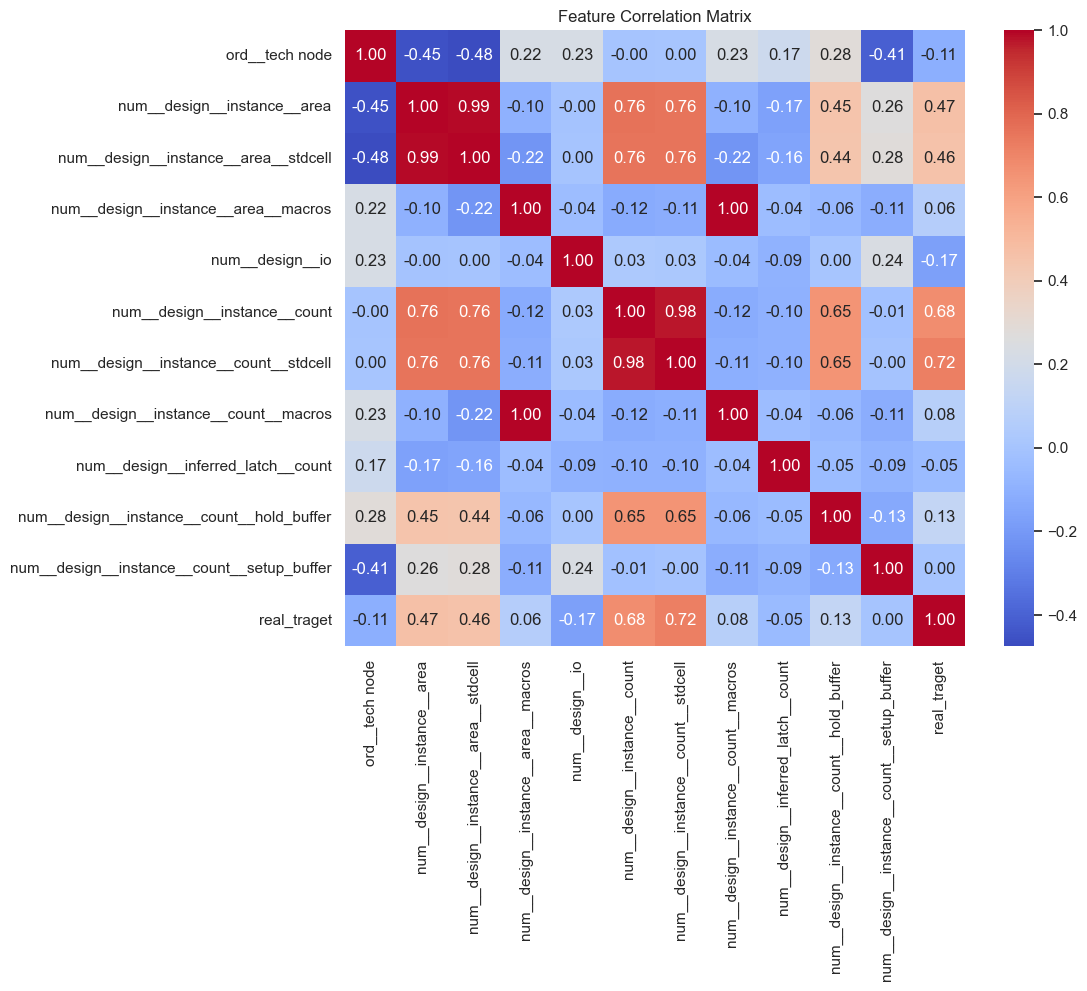

In [199]:
corr_matrix = X_balanced_feature.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

## Train Model

In [200]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train_final, Y_train_final)

y_predict = linear_model.predict(X_test_scaled)

mse = mean_squared_error(Y_test, y_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_predict)
r2 = r2_score(Y_test, y_predict)

print(f"MSE = {mse}\nRMSE = {rmse}\nMAE = {mae}\nR2 = {r2}")

MSE = 8009125518.468038
RMSE = 89493.7177597849
MAE = 29213.1227562281
R2 = 0.59695609610725


In [211]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

all_columns = X_train_final.columns.tolist()
numerical_cols = [col for col in all_columns if col != 'ord__tech node']
categorical_cols = ['ord__tech node']

numerical_transformer = PolynomialFeatures(degree=2, include_bias=False)

feature_expansion = ColumnTransformer(
    transformers=[
        ('poly_num', numerical_transformer, numerical_cols),
        ('cat', 'passthrough', categorical_cols)
    ]
)

pipeline = Pipeline([
    ('expansion', feature_expansion),
    ('regression', LinearRegression())
])

pipeline.fit(X_train_final, Y_train_final)


y_predict = pipeline.predict(X_test_scaled)

mse = mean_squared_error(Y_test, y_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_predict)
r2 = r2_score(Y_test, y_predict)

print(f"MSE = {mse}\nRMSE = {rmse}\nMAE = {mae}\nR2 = {r2}")

MSE = 248666909718.13913
RMSE = 498665.12783444073
MAE = 25151.693365894094
R2 = -11.513686023604148


In [212]:
from sklearn.ensemble import RandomForestRegressor

tree_model = RandomForestRegressor(n_estimators=100, random_state=148)

tree_model.fit(X_train_final, Y_train_final)


y_predict = tree_model.predict(X_test_scaled)

mse = mean_squared_error(Y_test, y_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_predict)
r2 = r2_score(Y_test, y_predict)

print(f"MSE = {mse}\nRMSE = {rmse}\nMAE = {mae}\nR2 = {r2}")

MSE = 1555565.0770674346
RMSE = 1247.2229460154406
MAE = 72.26123657073217
R2 = 0.9999217191664714


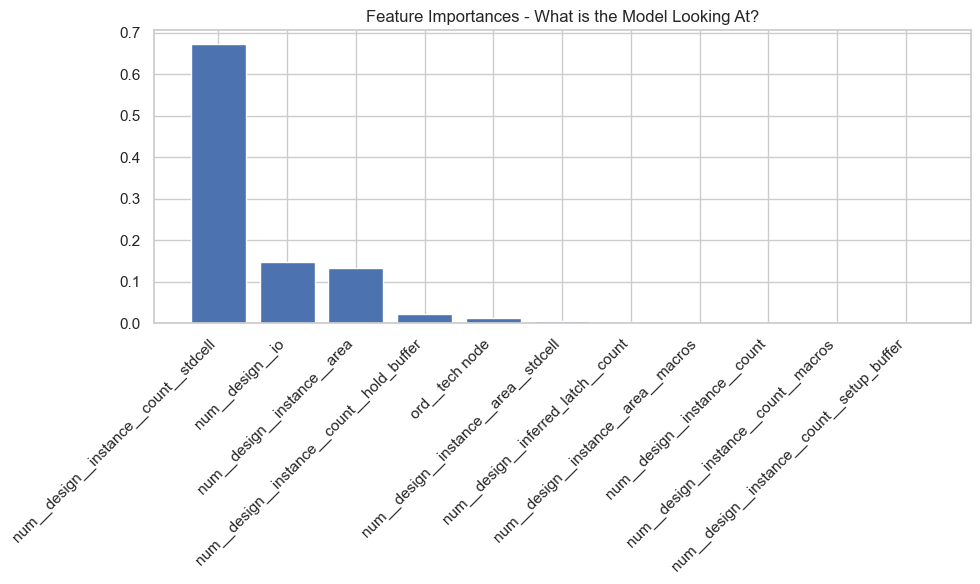

In [213]:
import numpy as np

# Extract feature importances from your trained random forest
importances = tree_model.feature_importances_
feature_names = X_train_scaled.columns

# Sort them in descending order
indices = np.argsort(importances)[::-1]

# Plot the top features
plt.figure(figsize=(10, 6))
plt.title("Feature Importances - What is the Model Looking At?")
plt.bar(range(X_train_scaled.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train_scaled.shape[1]), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()